# GPS Data Variance Analysis

This notebook analyzes the variance in GPS readings across different amphitheatretheatretheatretheatretheatretheatretheatretheatretheatretheaters.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
# Load the merged dataset
data_path = Path("../Data/ensia_gps_data .csv")
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst few rows:")
df.head()

Dataset shape: (8701, 24)
Columns: ['id', 'year', 'section', 'user', 'amphitheatre', 'module', 'seat_block', 'seat_row', 'seat_column', 'latitude_mean', 'longitude_mean', 'accuracy_mean', 'gps_variance', 'is_outside', 'sample_count', 'raw_gps_readings', 'collection_metadata', 'navigator_context', 'screen_context', 'network_information', 'battery_status', 'timestamp', 'created_at', 'device_info']

First few rows:


,id,year,section,user,amphitheatre,module,seat_block,seat_row,seat_column,latitude_mean,...,sample_count,raw_gps_readings,collection_metadata,navigator_context,screen_context,network_information,battery_status,timestamp,created_at,device_info
0,2,3.0,NaN,NaN,Amphi 3,Manual Selection,Center,3.0,6.0,36.687824,...,0,"[{'latitude': 36.687824, 'longitude': 2.86715,...","{'number_of_readings': 10, 'collection_duratio...","{'platform': 'Win32', 'user_agent': 'Mozilla/5...","{'avail_width': 1536, 'color_depth': 32, 'avai...","{'rtt_ms': 250, 'save_data': False, 'downlink_...","{'is_charging': False, 'battery_level': 0.96}",2026-03-05 07:28:56.580000+00:00,2026-03-05 07:29:01.758897+00:00,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
1,3,3.0,NaN,NaN,lab 8,Campus-wide Data,NaN,NaN,NaN,36.688127,...,0,"[{'latitude': 36.688126994584465, 'longitude':...","{'number_of_readings': 10, 'collection_duratio...","{'platform': 'Win32', 'user_agent': 'Mozilla/5...","{'avail_width': 1536, 'color_depth': 32, 'avai...","{'rtt_ms': 200, 'save_data': False, 'downlink_...","{'is_charging': False, 'battery_level': 0.76}",2026-03-05 10:00:57.029000+00:00,2026-03-05 10:00:56.927949+00:00,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
2,4,3.0,NaN,NaN,School entry,Campus-wide Data,NaN,NaN,NaN,36.688729,...,0,"[{'latitude': 36.6886848, 'longitude': 2.86555...","{'number_of_readings': 10, 'collection_duratio...","{'platform': 'Linux armv81', 'user_agent': 'Mo...","{'avail_width': 384, 'color_depth': 24, 'avail...","{'rtt_ms': 100, 'save_data': False, 'downlink_...","{'is_charging': False, 'battery_level': 0.77}",2026-03-05 10:15:16.599000+00:00,2026-03-05 10:15:16.067975+00:00,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...
3,5,3.0,NaN,NaN,Amphi 4,Manual Selection,Center,7.0,5.0,36.688630,...,0,"[{'latitude': 36.68863, 'longitude': 2.86675, ...","{'number_of_readings': 10, 'collection_duratio...","{'platform': 'Win32', 'user_agent': 'Mozilla/5...","{'avail_width': 1280, 'color_depth': 32, 'avai...","{'rtt_ms': 100, 'save_data': False, 'downlink_...","{'is_charging': True, 'battery_level': 1}",2026-03-06 15:20:11.927000+00:00,2026-03-06 15:20:12.063691+00:00,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
4,6,3.0,NaN,NaN,room,Campus-wide Data,NaN,NaN,NaN,36.688630,...,0,"[{'latitude': 36.68863, 'longitude': 2.86675, ...","{'number_of_readings': 10, 'collection_duratio...","{'platform': 'Win32', 'user_agent': 'Mozilla/5...","{'avail_width': 1280, 'color_depth': 32, 'avai...","{'rtt_ms': 100, 'save_data': False, 'downlink_...","{'is_charging': True, 'battery_level': 1}",2026-03-06 15:21:25.994000+00:00,2026-03-06 15:21:26.000699+00:00,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...


In [3]:
df.columns

Index(['id', 'year', 'section', 'user', 'amphitheatre', 'module', 'seat_block',
       'seat_row', 'seat_column', 'latitude_mean', 'longitude_mean',
       'accuracy_mean', 'gps_variance', 'is_outside', 'sample_count',
       'raw_gps_readings', 'collection_metadata', 'navigator_context',
       'screen_context', 'network_information', 'battery_status', 'timestamp',
       'created_at', 'device_info'],
      dtype='object')

In [4]:
# Standardize amphitheatretheater labels
# Keep amphitheatre 1-8, change everything else to "Outside"
valid_amphis = [f"Amphi {i}" for i in range(1, 9)]  # Amphi 1 through Amphi 8

print("Before standardization:")
print(f"Unique amphitheater labels: {df['amphitheatre'].unique()}")
print(f"Label counts:\n{df['amphitheatre'].value_counts()}")

# Replace non-standard labels with "Outside"
df['amphitheatre'] = df['amphitheatre'].apply(lambda x: x if x in valid_amphis else "Outside")

print("\nAfter standardization:")
print(f"Unique amphitheater labels: {df['amphitheatre'].unique()}")
print(f"Label counts:\n{df['amphitheatre'].value_counts()}")

# Verify we have the expected classes
expected_classes = valid_amphis + ["Outside"]
actual_classes = sorted(df['amphitheatre'].unique())
print(f"\nExpected classes: {expected_classes}")
print(f"Actual classes: {actual_classes}")
print(f"Classes match: {set(expected_classes) == set(actual_classes)}")

Before standardization:
Unique amphitheater labels: ['Amphi 3' 'lab 8' 'School entry' 'Amphi 4' 'room' 'end tarek' 'nasro '
 'mazalni end tarek' 'dorm' 'outside' 'Amphi 5' 'Amphi 1' 'Outside'
 'Amphi 7' 'Amphi 2' 'Hfgnffn' 'Amphi 6' 'Nasro' 'Mdpres end tarek'
 'SkillnTell Spot ' 'Spot ' 'Amphi 8' 'maalma3' "Salle d'études"
 'Salle d’études' 'Amphi 3 door 2 ' 'Amphi 3 door 1 ' 'AMPHI8' 'Hall'
 'tuto23' 'Dorms' 'Lab 8' 'study room' 'In front of amphi 8' 'Lab 7 '
 'lkhadra']
Label counts:
amphitheatre
Amphi 2                2565
Amphi 5                1359
Amphi 8                 989
Amphi 6                 936
Amphi 4                 741
Outside                 658
Amphi 1                 625
Amphi 3                 318
Amphi 7                 122
Nasro                   100
Mdpres end tarek         46
maalma3                  33
Dorms                    21
SkillnTell Spot          20
Salle d'études           20
Hall                     10
AMPHI8                   10
nasro               

In [5]:
df['amphitheatre'].value_counts()

amphitheatre
Amphi 2    2565
Amphi 5    1359
Outside    1046
Amphi 8     989
Amphi 6     936
Amphi 4     741
Amphi 1     625
Amphi 3     318
Amphi 7     122
Name: count, dtype: int64

In [6]:
# Function to calculate variance for each reading
def calculate_reading_variance(row):
    """
    Calculate the variance of GPS coordinates within a single reading's RawReadings
    """
    try:
        # Parse the JSON RawReadings
        readings = json.loads(row['RawReadings'])
        
        if not readings:
            return np.nan
        
        # Extract latitude and longitude
        lats = [r['latitude'] for r in readings]
        lngs = [r['longitude'] for r in readings]
        
        # Calculate variance for lat and lng separately, then combine
        lat_var = np.var(lats) if len(lats) > 1 else 0
        lng_var = np.var(lngs) if len(lngs) > 1 else 0
        
        # Return combined variance (sum of variances)
        return lat_var + lng_var
        
    except (json.JSONDecodeError, KeyError, TypeError):
        return np.nan

# Apply the function to calculate variance for each row
df['calculated_variance'] = df.apply(calculate_reading_variance, axis=1)

print("Variance calculation completed.")
print(f"Number of valid variance calculations: {df['calculated_variance'].notna().sum()}")
print(f"Number of NaN variances: {df['calculated_variance'].isna().sum()}")

Variance calculation completed.
Number of valid variance calculations: 0
Number of NaN variances: 8701


Example raw reading:
[]
lats: []...
lngs: []...


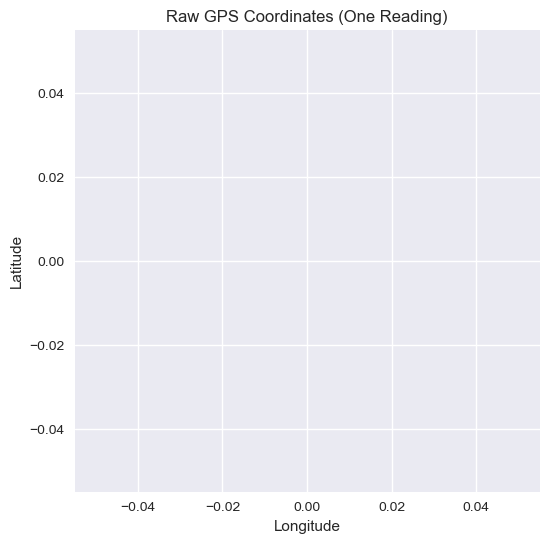

In [7]:
# Pick one valid row with RawReadings
example_row = df.dropna(subset=['raw_gps_readings']).iloc[30]

# Parse JSON raw readings
readings = json.loads(example_row['raw_gps_readings'])

# Print example raw reading (first point)
print("Example raw reading:")
print(readings)

# Extract coordinates
lats = [r['latitude'] for r in readings]
lngs = [r['longitude'] for r in readings]
print(f"lats: {lats[:]}...")  
print (f"lngs: {lngs[:]}...") 
# Plot raw GPS coordinates
plt.figure(figsize=(6, 6))
plt.scatter(lngs, lats)

plt.title("Raw GPS Coordinates (One Reading)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.grid(True)
plt.show()

In [8]:
# Basic statistics of calculated variance
print("Variance Statistics:")
print(df['calculated_variance'].describe())

# Compare with existing Variance column
print("\nExisting Variance column statistics:")
print(df['Variance'].describe())

# Check correlation
correlation = df[['calculated_variance', 'Variance']].corr()
print(f"\nCorrelation between calculated and existing variance: {correlation.iloc[0,1]:.4f}")

Variance Statistics:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: calculated_variance, dtype: float64

Existing Variance column statistics:


KeyError: 'Variance'

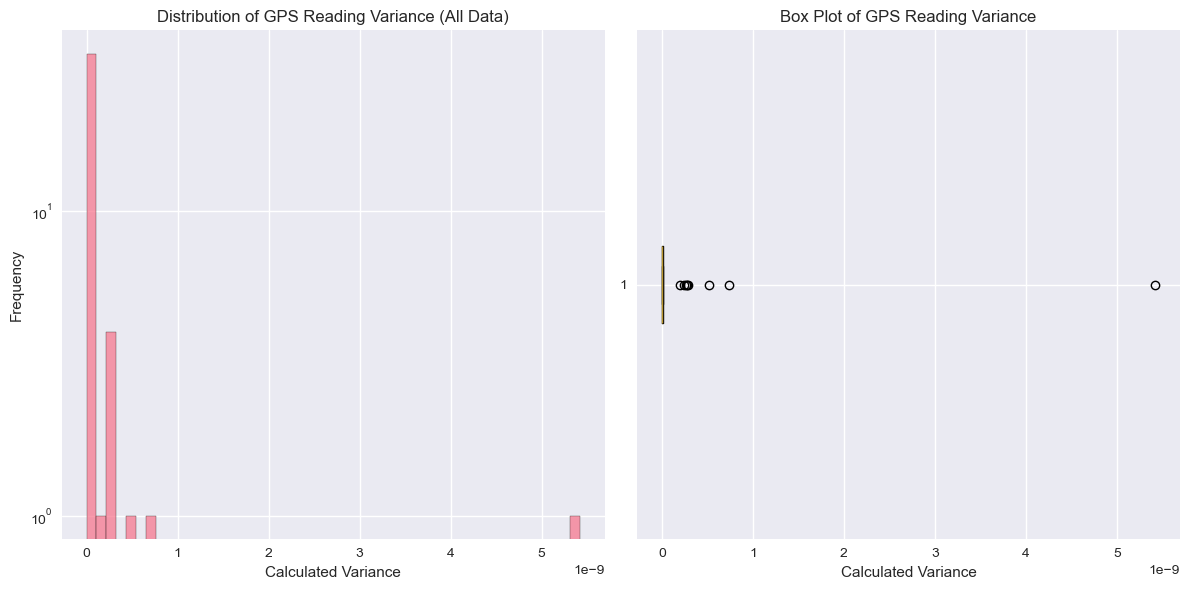

Variance range: 0.00e+00 to 5.42e-09
Median variance: 5.07e-29


In [ ]:
# Plot overall distribution of calculated variance
plt.figure(figsize=(12, 6))

# Remove NaN values for plotting
variance_data = df['calculated_variance'].dropna()

plt.subplot(1, 2, 1)
plt.hist(variance_data, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Calculated Variance')
plt.ylabel('Frequency')
plt.title('Distribution of GPS Reading Variance (All Data)')
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.boxplot(variance_data, vert=False)
plt.xlabel('Calculated Variance')
plt.title('Box Plot of GPS Reading Variance')

plt.tight_layout()
plt.show()

print(f"Variance range: {variance_data.min():.2e} to {variance_data.max():.2e}")
print(f"Median variance: {variance_data.median():.2e}")

ValueError: Could not interpret value `Amphi` for `x`. An entry with this name does not appear in `data`.

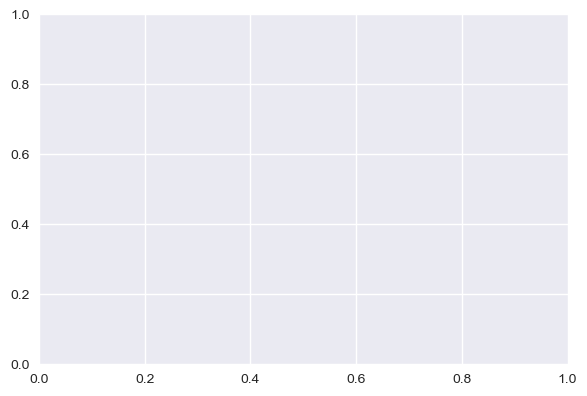

In [9]:
# Plot variance distribution by amphitheater
plt.figure(figsize=(15, 10))

# Filter out NaN variances and prepare data
plot_data = df.dropna(subset=['calculated_variance'])

# Create box plot by amphitheater
plt.subplot(2, 2, 1)
sns.boxplot(data=plot_data, x='Amphi', y='calculated_variance')
plt.xticks(rotation=45)
plt.ylabel('Calculated Variance')
plt.title('Variance Distribution by Amphitheater (Box Plot)')
plt.yscale('log')

# Create violin plot by amphitheater
plt.subplot(2, 2, 2)
sns.violinplot(data=plot_data, x='Amphi', y='calculated_variance')
plt.xticks(rotation=45)
plt.ylabel('Calculated Variance')
plt.title('Variance Distribution by Amphitheater (Violin Plot)')
plt.yscale('log')

# Create strip plot
plt.subplot(2, 2, 3)
sns.stripplot(data=plot_data, x='Amphi', y='calculated_variance', alpha=0.6, jitter=True)
plt.xticks(rotation=45)
plt.ylabel('Calculated Variance')
plt.title('Variance Distribution by Amphitheater (Strip Plot)')
plt.yscale('log')

# Create bar plot of mean variance by amphitheater
plt.subplot(2, 2, 4)
mean_variance_by_amphi = plot_data.groupby('Amphi')['calculated_variance'].mean().sort_values()
mean_variance_by_amphi.plot(kind='bar', rot=45)
plt.ylabel('Mean Calculated Variance')
plt.title('Mean Variance by Amphitheater')
plt.yscale('log')

plt.tight_layout()
plt.show()

In [10]:
# Statistical summary by amphitheater
print("Variance Statistics by Amphitheater:")
variance_stats = plot_data.groupby('Amphi')['calculated_variance'].agg([
    'count', 'mean', 'std', 'min', 'max', 'median'
]).round(6)
print(variance_stats)

# Sort by mean variance
print("\nSorted by Mean Variance:")
print(variance_stats.sort_values('mean', ascending=False))

Variance Statistics by Amphitheater:
                   count  mean  std  min  max  median
Amphi                                                
Amphi 1                4   0.0  0.0  0.0  0.0     0.0
Amphi 2                3   0.0  0.0  0.0  0.0     0.0
Amphi 3                1   0.0  NaN  0.0  0.0     0.0
Amphi 4                1   0.0  NaN  0.0  0.0     0.0
Amphi 5              137   0.0  0.0  0.0  0.0     0.0
Amphi 6              170   0.0  0.0  0.0  0.0     0.0
Amphi 7               12   0.0  0.0  0.0  0.0     0.0
School entry           1   0.0  NaN  0.0  0.0     0.0
dorm                   1   0.0  NaN  0.0  0.0     0.0
end tarek              1   0.0  NaN  0.0  0.0     0.0
lab 8                  1   0.0  NaN  0.0  0.0     0.0
mazalni end tarek      1   0.0  NaN  0.0  0.0     0.0
outside                1   0.0  NaN  0.0  0.0     0.0
room                   1   0.0  NaN  0.0  0.0     0.0

Sorted by Mean Variance:
                   count  mean  std  min  max  median
Amphi              

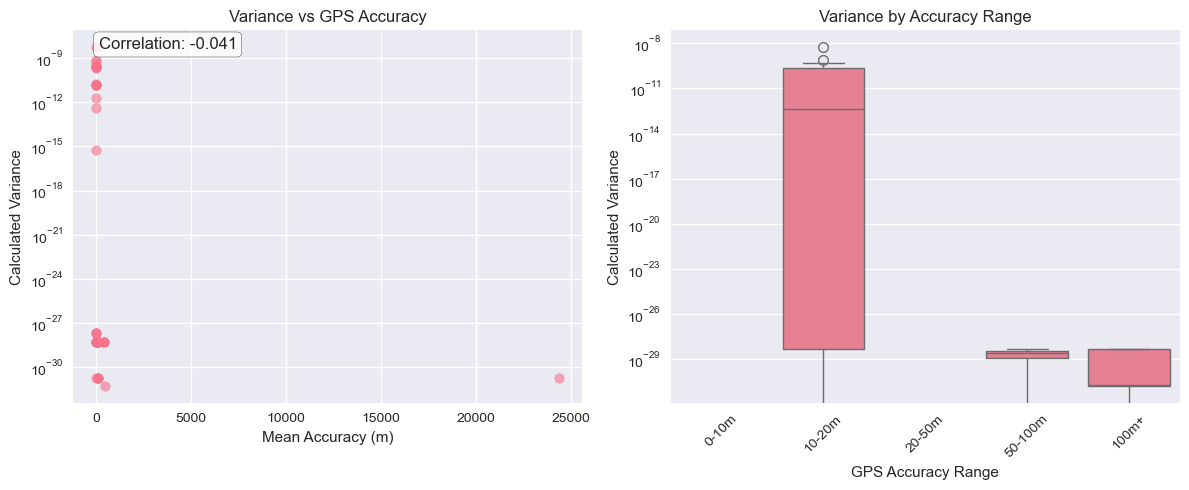

In [20]:
# Analyze variance vs accuracy
plt.figure(figsize=(12, 5))

# Scatter plot of variance vs accuracy
plt.subplot(1, 2, 1)
valid_data = df.dropna(subset=['calculated_variance', 'Acc_Mean'])
plt.scatter(valid_data['Acc_Mean'], valid_data['calculated_variance'], alpha=0.6)
plt.xlabel('Mean Accuracy (m)')
plt.ylabel('Calculated Variance')
plt.title('Variance vs GPS Accuracy')
plt.yscale('log')

# Correlation coefficient
corr = valid_data[['Acc_Mean', 'calculated_variance']].corr().iloc[0,1]
plt.text(0.05, 0.95, f'Correlation: {corr:.3f}', 
         transform=plt.gca().transAxes, fontsize=12, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Box plot of variance by accuracy ranges
plt.subplot(1, 2, 2)
valid_data['accuracy_range'] = pd.cut(valid_data['Acc_Mean'], 
                                     bins=[0, 10, 20, 50, 100, float('inf')],
                                     labels=['0-10m', '10-20m', '20-50m', '50-100m', '100m+'])
sns.boxplot(data=valid_data, x='accuracy_range', y='calculated_variance')
plt.ylabel('Calculated Variance')
plt.xlabel('GPS Accuracy Range')
plt.title('Variance by Accuracy Range')
plt.xticks(rotation=45)
plt.yscale('log')

plt.tight_layout()
plt.show()

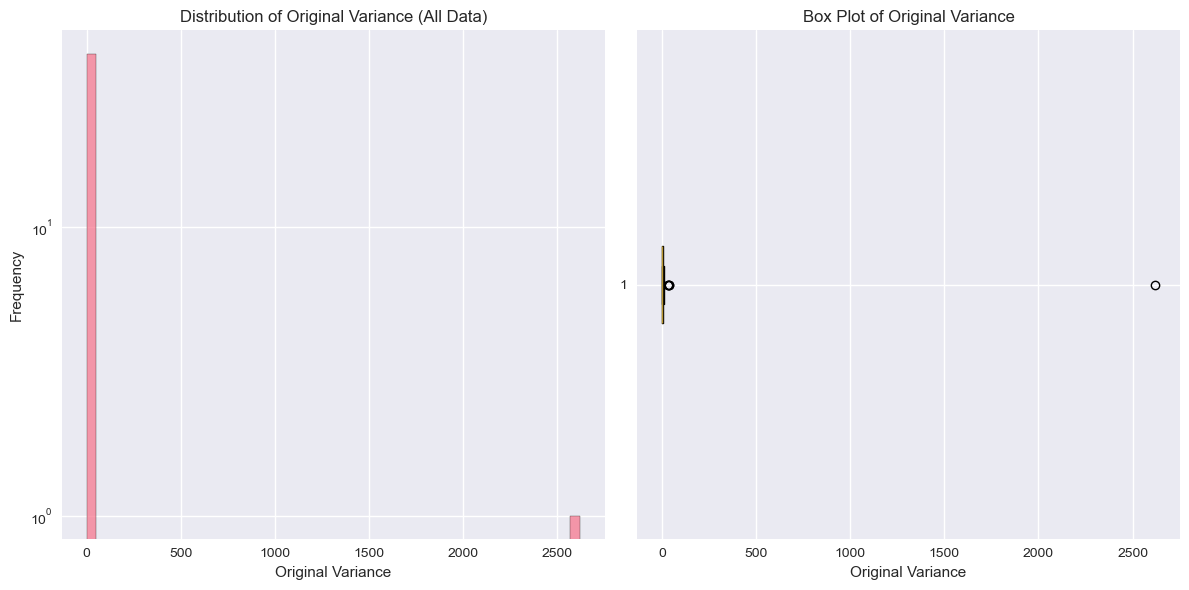

Original Variance range: 0.00e+00 to 2.62e+03
Median original variance: 0.00e+00


In [41]:
# Plot distribution of original Variance column
plt.figure(figsize=(12, 6))

# Remove NaN values for plotting
original_variance_data = df["Variance"].dropna()

plt.subplot(1, 2, 1)
plt.hist(original_variance_data, bins=50, alpha=0.7, edgecolor="black")
plt.xlabel("Original Variance")
plt.ylabel("Frequency")
plt.title("Distribution of Original Variance (All Data)")
plt.yscale("log")

plt.subplot(1, 2, 2)
plt.boxplot(original_variance_data, vert=False)
plt.xlabel("Original Variance")
plt.title("Box Plot of Original Variance")

plt.tight_layout()
plt.show()

print(f"Original Variance range: {original_variance_data.min():.2e} to {original_variance_data.max():.2e}")
print(f"Median original variance: {original_variance_data.median():.2e}")

Calculated Variance Outliers:
Number of outliers: 8
Percentage of outliers: 19.51%
IQR bounds: [-2.40e-11, 3.99e-11]
Outlier range: [1.99e-10, 5.42e-09]


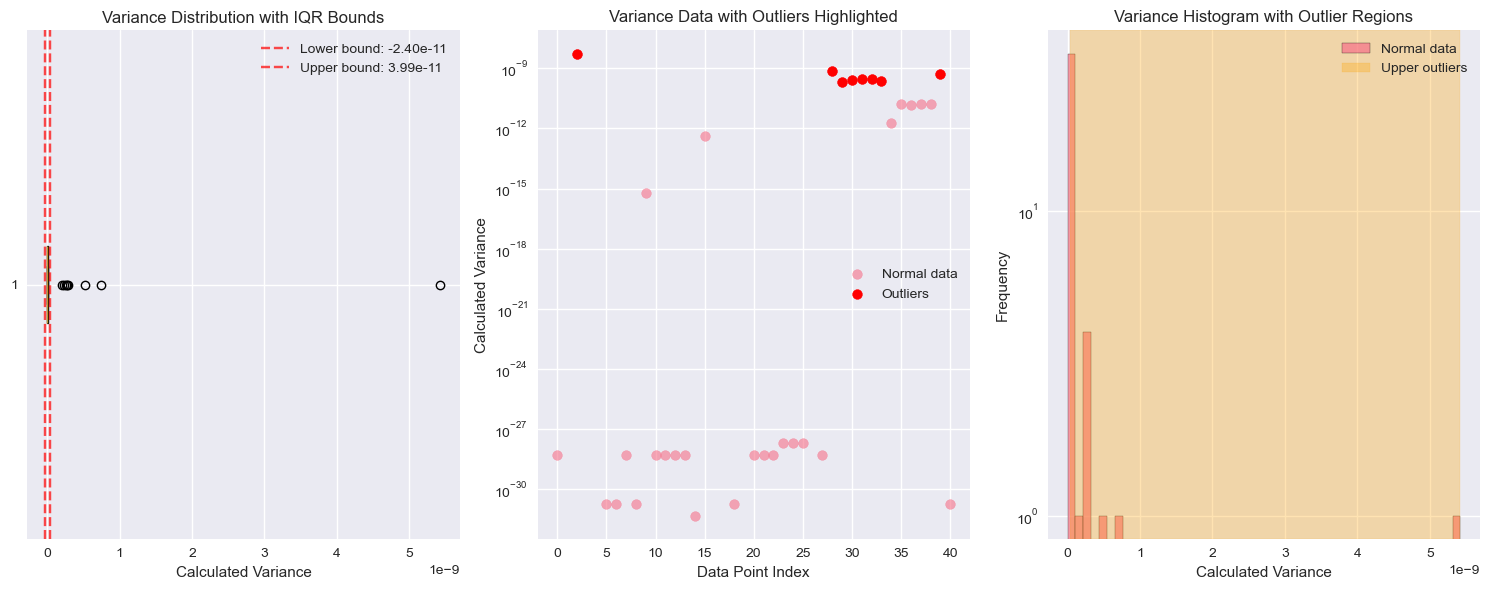


Top 10 outliers (by value):
Index 2: Variance = 5.42e-09, Amphitheater = Outside
Index 28: Variance = 7.40e-10, Amphitheater = Amphi 1
Index 39: Variance = 5.16e-10, Amphitheater = Amphi 7
Index 32: Variance = 2.85e-10, Amphitheater = Amphi 7
Index 31: Variance = 2.78e-10, Amphitheater = Amphi 7
Index 30: Variance = 2.63e-10, Amphitheater = Amphi 7
Index 33: Variance = 2.39e-10, Amphitheater = Amphi 7
Index 29: Variance = 1.99e-10, Amphitheater = Amphi 7


In [43]:
# Plot outliers in the variance data
import numpy as np

# Function to identify outliers using IQR method
def identify_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers, lower_bound, upper_bound

# Identify outliers in calculated variance
variance_data = df['calculated_variance'].dropna()
outliers, lower_bound, upper_bound = identify_outliers_iqr(variance_data)

print(f"Calculated Variance Outliers:")
print(f"Number of outliers: {len(outliers)}")
print(f"Percentage of outliers: {(len(outliers)/len(variance_data)*100):.2f}%")
print(f"IQR bounds: [{lower_bound:.2e}, {upper_bound:.2e}]")
print(f"Outlier range: [{outliers.min():.2e}, {outliers.max():.2e}]")

# Plot outliers
plt.figure(figsize=(15, 6))

# Subplot 1: Box plot with outliers highlighted
plt.subplot(1, 3, 1)
plt.boxplot(variance_data, vert=False, patch_artist=True)
plt.axvline(lower_bound, color='red', linestyle='--', alpha=0.7, label=f'Lower bound: {lower_bound:.2e}')
plt.axvline(upper_bound, color='red', linestyle='--', alpha=0.7, label=f'Upper bound: {upper_bound:.2e}')
plt.xlabel('Calculated Variance')
plt.title('Variance Distribution with IQR Bounds')
plt.legend()

# Subplot 2: Scatter plot of all data with outliers highlighted
plt.subplot(1, 3, 2)
plt.scatter(range(len(variance_data)), variance_data, alpha=0.6, label='Normal data')
if len(outliers) > 0:
    outlier_indices = variance_data[variance_data.isin(outliers)].index
    outlier_positions = [variance_data.index.get_loc(idx) for idx in outlier_indices]
    plt.scatter(outlier_positions, outliers, color='red', s=50, label='Outliers')
plt.ylabel('Calculated Variance')
plt.xlabel('Data Point Index')
plt.title('Variance Data with Outliers Highlighted')
plt.yscale('log')
plt.legend()

# Subplot 3: Histogram with outlier regions shaded
plt.subplot(1, 3, 3)
counts, bins, patches = plt.hist(variance_data, bins=50, alpha=0.7, edgecolor='black', label='Normal data')

# Shade outlier regions
if lower_bound > variance_data.min():
    plt.axvspan(variance_data.min(), lower_bound, alpha=0.3, color='red', label='Lower outliers')
if upper_bound < variance_data.max():
    plt.axvspan(upper_bound, variance_data.max(), alpha=0.3, color='orange', label='Upper outliers')

plt.xlabel('Calculated Variance')
plt.ylabel('Frequency')
plt.title('Variance Histogram with Outlier Regions')
plt.yscale('log')
plt.legend()

plt.tight_layout()
plt.show()

# Show outlier details
if len(outliers) > 0:
    print("\nTop 10 outliers (by value):")
    top_outliers = outliers.nlargest(10)
    for idx, val in top_outliers.items():
        amphi = df.loc[idx, 'Amphi']
        print(f"Index {idx}: Variance = {val:.2e}, Amphitheater = {amphi}")

In [46]:
# Update the original Variance column with calculated variance values
print("Before update - Original Variance column statistics:")
print(df['Variance'].describe())

# Update the Variance column with calculated values, keeping NaN where calculation failed
df['Variance'] = df['calculated_variance']

print("\nAfter update - Variance column statistics:")
print(df['Variance'].describe())

# Save the updated dataset
output_path = "../Data/ensia_gps_data_v1.csv"
df.to_csv(output_path, index=False)

print(f"\nUpdated dataset saved to: {output_path}")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Verify the update
print("\nVerification - First few rows of updated Variance column:")
print(df[['Amphi', 'Variance']].head())

Before update - Original Variance column statistics:
count    4.100000e+01
mean     1.953082e-10
std      8.510339e-10
min      0.000000e+00
25%      1.972152e-31
50%      5.068431e-29
75%      1.597934e-11
max      5.421720e-09
Name: Variance, dtype: float64

After update - Variance column statistics:
count    4.100000e+01
mean     1.953082e-10
std      8.510339e-10
min      0.000000e+00
25%      1.972152e-31
50%      5.068431e-29
75%      1.597934e-11
max      5.421720e-09
Name: Variance, dtype: float64

Updated dataset saved to: ../Data/ensia_gps_data_v1.csv
Dataset shape: (41, 20)
Columns: ['ID', 'Timestamp', 'Year', 'Amphi', 'Module', 'Block', 'Row', 'Column', 'Lat_Mean', 'Lng_Mean', 'Acc_Mean', 'Variance', 'IsOutside', 'RawReadings', 'Metadata', 'NavigatorContext', 'ScreenContext', 'NetworkInfo', 'BatteryStatus', 'calculated_variance']

Verification - First few rows of updated Variance column:
     Amphi      Variance
0  Amphi 3  5.068431e-29
1  Outside  0.000000e+00
2  Outside  

In [45]:

# Compute variance for record ID 4
print("=== Variance Calculation for Record ID 4 ===")

# Filter for record ID 4
record_4 = df[df['ID'] == 4]

if len(record_4) == 0:
    print("Record ID 4 not found in dataset")
else:
    record = record_4.iloc[0]
    print(f"Record ID: {record['ID']}")
    print(f"Amphitheater: {record['Amphi']}")
    print(f"RawReadings length: {len(record['RawReadings'])} characters")
    
    # Parse RawReadings JSON
    try:
        readings = json.loads(record['RawReadings'])
        print(f"\nNumber of GPS readings: {len(readings)}")
        
        # Extract coordinates
        lats = [r['latitude'] for r in readings]
        lngs = [r['longitude'] for r in readings]
        
        print(f"\nLatitude values: {lats}")
        print(f"Longitude values: {lngs}")
        
        # Calculate variances
        lat_var = np.var(lats) if len(lats) > 1 else 0
        lng_var = np.var(lngs) if len(lngs) > 1 else 0
        total_var = lat_var + lng_var
        
        print(f"\nVariance calculations:")
        print(f"Latitude variance: {lat_var:.2e}")
        print(f"Longitude variance: {lng_var:.2e}")
        print(f"Total variance (lat + lng): {total_var:.2e}")
        
        # Compare with stored variance
        stored_var = record['Variance']
        print(f"\nStored variance in dataset: {stored_var:.2e}")
        print(f"Match: {abs(total_var - stored_var) < 1e-10}")
        
        # Mean values
        lat_mean = np.mean(lats)
        lng_mean = np.mean(lngs)
        
        print(f"\nCoordinate analysis:")
        print(f"Mean latitude: {lat_mean:.6f}")
        print(f"Mean longitude: {lng_mean:.6f}")
        
        print("\nLatitude deviations from mean:")
        for i, lat in enumerate(lats):
            dev = lat - lat_mean
            print(f"{lat:.6f} | deviation: {dev:.6f}")
        
        print("\nLongitude deviations from mean:")
        for i, lng in enumerate(lngs):
            dev = lng - lng_mean
            print(f"{lng:.6f} | deviation: {dev:.6f}")
            
    except json.JSONDecodeError as e:
        print(f"Error parsing JSON: {e}")
    except KeyError as e:
        print(f"Missing key in readings: {e}")

=== Variance Calculation for Record ID 4 ===
Record ID: 4
Amphitheater: Outside
RawReadings length: 2240 characters

Number of GPS readings: 10

Latitude values: [36.6886848, 36.6886848, 36.6886848, 36.6886848, 36.6886848, 36.6886848, 36.6887951, 36.6887951, 36.6887951, 36.6887951]
Longitude values: [2.8655548, 2.8655548, 2.8655548, 2.8655548, 2.8655548, 2.8655548, 2.8656569, 2.8656569, 2.8656569, 2.8656569]

Variance calculations:
Latitude variance: 2.92e-09
Longitude variance: 2.50e-09
Total variance (lat + lng): 5.42e-09

Stored variance in dataset: 5.42e-09
Match: True

Coordinate analysis:
Mean latitude: 36.688729
Mean longitude: 2.865596

Latitude deviations from mean:
36.688685 | deviation: -0.000044
36.688685 | deviation: -0.000044
36.688685 | deviation: -0.000044
36.688685 | deviation: -0.000044
36.688685 | deviation: -0.000044
36.688685 | deviation: -0.000044
36.688795 | deviation: 0.000066
36.688795 | deviation: 0.000066
36.688795 | deviation: 0.000066
36.688795 | deviation:

# Altitude 

=== ALTITUDE ANALYSIS SUMMARY ===

1. NULL VALUES ANALYSIS:
   Total records: 41
   Records with altitude data: 28
   Records with null altitude: 13

   Null altitude distribution by amphitheater:
   Outside: 6 records
   Amphi 1: 3 records
   Amphi 2: 2 records
   Amphi 3: 1 records
   Amphi 4: 1 records

2. PLATFORM CORRELATION:
   Platform distribution:
   Win32: 9 records
   Linux aarch64: 9 records
   Linux armv8l: 8 records
   Linux armv81: 6 records
   Linux armv7l: 4 records
   iPhone: 4 records
   Linux x86_64: 1 records

   Altitude statistics by platform:
   Linux armv81:
     Count: 70
     Mean: 184.04m
     Std: 6.80m
     Min: 181.20m
     Max: 203.00m
   iPhone:
     Count: 40
     Mean: 104.94m
     Std: 41.99m
     Min: 32.22m
     Max: 129.49m
   Linux armv7l:
     Count: 10
     Mean: 191.10m
     Std: 0.00m
     Min: 191.10m
     Max: 191.10m
   Linux aarch64:
     Count: 102
     Mean: 181.43m
     Std: 0.25m
     Min: 181.20m
     Max: 181.70m
   Linux armv8l:
  

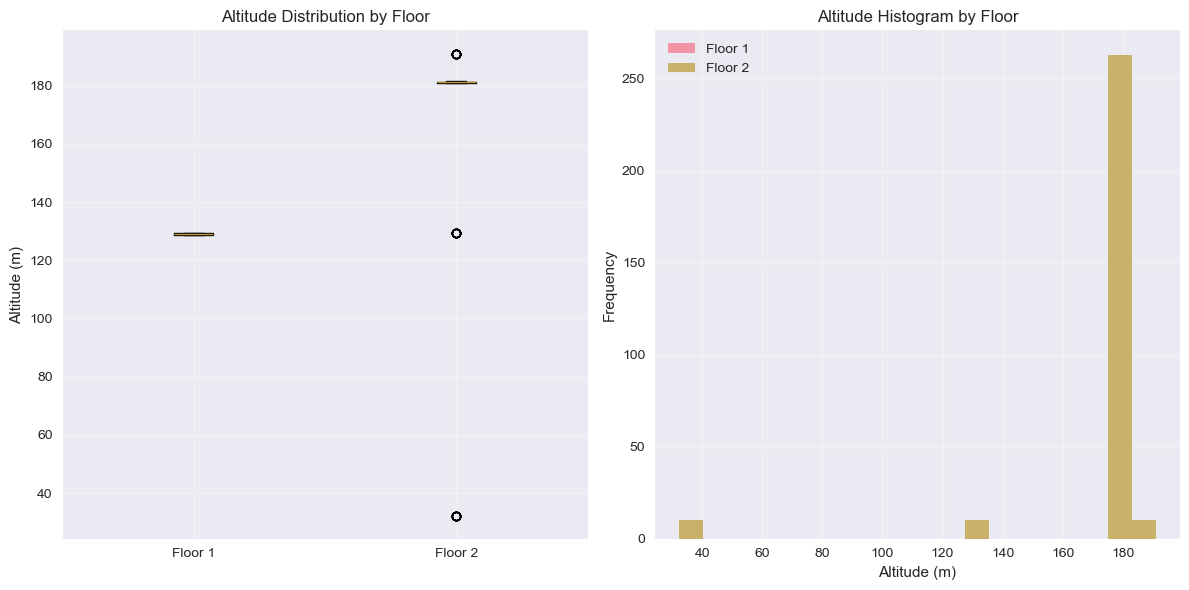

In [50]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Function to extract altitude from RawReadings
def extract_altitude(row):
    """Extract altitude values from RawReadings JSON"""
    try:
        readings = json.loads(row['RawReadings'])
        altitudes = []
        for reading in readings:
            if 'altitude_m' in reading and reading['altitude_m'] is not None:
                altitudes.append(reading['altitude_m'])
        return altitudes if altitudes else None
    except:
        return None


print("=== ALTITUDE ANALYSIS SUMMARY ===\n")

# Extract altitudes
df['altitude_list'] = df.apply(extract_altitude, axis=1)

# Basic stats
total_records = len(df)
altitude_records = df['altitude_list'].notna().sum()
null_altitude_records = df['altitude_list'].isna().sum()

print("1. NULL VALUES ANALYSIS:")
print(f"   Total records: {total_records}")
print(f"   Records with altitude data: {altitude_records}")
print(f"   Records with null altitude: {null_altitude_records}")

# Null values by amphitheater
print("\n   Null altitude distribution by amphitheater:")
null_by_amphi = df[df['altitude_list'].isna()]['Amphi'].value_counts()
for amphi, count in null_by_amphi.items():
    print(f"   {amphi}: {count} records")


# 2. PLATFORM CORRELATION
print("\n2. PLATFORM CORRELATION:")

if 'NavigatorContext' in df.columns:

    def extract_platform(row):
        try:
            nav_context = json.loads(row['NavigatorContext'])
            return nav_context.get('platform', 'Unknown')
        except:
            return 'Unknown'

    df['platform'] = df.apply(extract_platform, axis=1)

    print("   Platform distribution:")
    platform_counts = df['platform'].value_counts()
    for platform, count in platform_counts.items():
        print(f"   {platform}: {count} records")

    print("\n   Altitude statistics by platform:")
    for platform in df['platform'].unique():
        platform_data = df[df['platform'] == platform]

        platform_altitudes = []
        for alt_list in platform_data['altitude_list'].dropna():
            platform_altitudes.extend(alt_list)

        if platform_altitudes:
            print(f"   {platform}:")
            print(f"     Count: {len(platform_altitudes)}")
            print(f"     Mean: {np.mean(platform_altitudes):.2f}m")
            print(f"     Std: {np.std(platform_altitudes):.2f}m")
            print(f"     Min: {np.min(platform_altitudes):.2f}m")
            print(f"     Max: {np.max(platform_altitudes):.2f}m")
else:
    print("   NavigatorContext column not found")


# 3. FLOOR ANALYSIS
print("\n3. FLOOR-BASED ANALYSIS:")

floor1_amphis = ['Amphi 1', 'Amphi 2', 'Amphi 3', 'Amphi 4']
floor2_amphis = ['Amphi 5', 'Amphi 6', 'Amphi 7', 'Amphi 8']


def calculate_floor_stats(amphis, floor_name):
    floor_data = df[df['Amphi'].isin(amphis)]
    floor_altitudes = []

    for alt_list in floor_data['altitude_list'].dropna():
        floor_altitudes.extend(alt_list)

    print(f"\n   {floor_name} ({', '.join(amphis)}):")
    print(f"     Records in floor: {len(floor_data)}")
    print(f"     Records with altitude: {floor_data['altitude_list'].notna().sum()}")

    if floor_altitudes:
        print(f"     Altitude readings: {len(floor_altitudes)}")
        print(f"     Mean altitude: {np.mean(floor_altitudes):.2f}m")
        print(f"     Median altitude: {np.median(floor_altitudes):.2f}m")
        print(f"     Std deviation: {np.std(floor_altitudes):.2f}m")
        print(f"     Min altitude: {np.min(floor_altitudes):.2f}m")
        print(f"     Max altitude: {np.max(floor_altitudes):.2f}m")
        return floor_altitudes
    else:
        print("     No altitude data available")
        return []


floor1_altitudes = calculate_floor_stats(floor1_amphis, "Floor 1")
floor2_altitudes = calculate_floor_stats(floor2_amphis, "Floor 2")


# 4. COMPARISON
if floor1_altitudes and floor2_altitudes:
    print("\n4. FLOOR COMPARISON:")
    print(f"   Floor 1 mean: {np.mean(floor1_altitudes):.2f}m")
    print(f"   Floor 2 mean: {np.mean(floor2_altitudes):.2f}m")
    print(f"   Difference: {np.mean(floor2_altitudes) - np.mean(floor1_altitudes):.2f}m")

    t_stat, p_value = stats.ttest_ind(floor1_altitudes, floor2_altitudes)
    print(f"   T-test: t={t_stat:.3f}, p={p_value:.4f}")
    print(f"   Significant difference: {p_value < 0.05}")


# 5. OVERALL STATS
print("\n5. OVERALL ALTITUDE STATISTICS:")

all_altitudes = []
for alt_list in df['altitude_list'].dropna():
    all_altitudes.extend(alt_list)

if all_altitudes:
    print(f"   Total altitude readings: {len(all_altitudes)}")
    print(f"   Overall mean: {np.mean(all_altitudes):.2f}m")
    print(f"   Overall median: {np.median(all_altitudes):.2f}m")
    print(f"   Overall std: {np.std(all_altitudes):.2f}m")
    print(f"   Range: {np.min(all_altitudes):.2f}m - {np.max(all_altitudes):.2f}m")


# 6. VISUALIZATION
if floor1_altitudes and floor2_altitudes:
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.boxplot([floor1_altitudes, floor2_altitudes], labels=['Floor 1', 'Floor 2'])
    plt.ylabel('Altitude (m)')
    plt.title('Altitude Distribution by Floor')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.hist(floor1_altitudes, alpha=0.7, label='Floor 1', bins=20)
    plt.hist(floor2_altitudes, alpha=0.7, label='Floor 2', bins=20)
    plt.xlabel('Altitude (m)')
    plt.ylabel('Frequency')
    plt.title('Altitude Histogram by Floor')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()